pancreas dataset from https://figshare.com/articles/dataset/scIB_pancreas_dataset/25953868

In [1]:
import scanpy as sc
import anndata
import pytorch_lightning as pl  
from scdiff.dataset import ScDataModule
from scdiff.ae import LightningAE
import os
import numpy as np
import pandas as pd

# Find Batch Effects in AE latent sapce

In [ ]:
pancreas = anndata.read_h5ad('../data/scIBPancreas.h5ad')
pancreas.obs

In [3]:
from scdiff.transform import NormalLog1pScaler

display(pancreas.obs['tech'].unique())
pancreas_scaler = NormalLog1pScaler()
pancreas.X = pancreas_scaler.fit_transform(pancreas.X)

['celseq', 'celseq2', 'fluidigmc1', 'smartseq2', 'inDrop1', 'inDrop2', 'inDrop3', 'inDrop4', 'smarter']
Categories (9, object): ['celseq', 'celseq2', 'fluidigmc1', 'inDrop1', ..., 'inDrop3', 'inDrop4', 'smarter', 'smartseq2']

In [4]:
pancreasModule = ScDataModule(pancreas, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=pancreas.X.shape[1])

log_dir = "../lightning_logs/pancreas/ae"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=log_dir
)

ae_path = "checkpoints/pancreas/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, pancreasModule)
    trainer.save_checkpoint(ae_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [5]:
import torch
from sklearn.preprocessing import StandardScaler

device = next(ae.parameters()).device
X_tensor = torch.tensor(pancreas.X, dtype=torch.float32).to(device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()
X_encoded.shape

(16382, 128)

In [8]:
batch_labels = pancreas.obs['tech']
batch_labels.shape

(16382,)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/tqdm/auto.py:21: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-11.03297   ,  13.3297    ],
        [-10.865371  ,  13.395873  ],
        [-10.819394  ,  13.404272  ],
        ...,
        [ 15.703993  ,   0.27635813],
        [ 15.714256  ,   0.07606439],
        [ 15.859944  ,   0.39904925]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

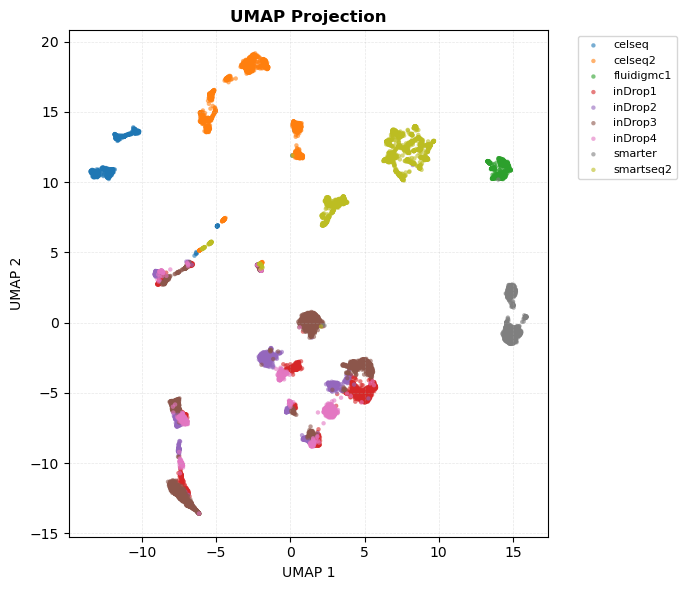

In [9]:
from scdiff.plot import umap_plot
umap_plot(X_encoded, batch_labels)

Batch Effects averaged over cell types

In [10]:
from scdiff.control import batch_directions 
cell_types = pancreas.obs['celltype']
batch_effects = batch_directions(X_encoded, batch_labels, cell_types=cell_types)
batch_effects

,celseq,celseq2,fluidigmc1,inDrop1,inDrop2,inDrop3,inDrop4,smarter,smartseq2
0,0.0,-0.768353,-5.092894,-1.109180,-2.357223,-1.460463,-1.937456,0.471786,-0.347178
1,0.0,-0.511896,-3.808590,-0.430479,-0.096033,0.118800,-0.308315,-1.992328,-0.154325
2,0.0,-0.125656,1.710801,1.205488,-0.020084,1.206460,0.128351,-0.550084,-0.601298
3,0.0,-0.909911,-0.312746,1.297573,0.025983,0.586978,1.172827,-0.184655,-1.585427
4,0.0,-0.719781,-2.711668,-3.060656,-3.139222,-3.044126,-2.483045,-1.215485,-0.957141
...,...,...,...,...,...,...,...,...,...
123,0.0,1.545932,0.629789,1.489183,2.002450,0.398463,1.572530,0.153586,1.251789
124,0.0,-1.679550,0.975188,0.913201,0.992033,1.912847,1.801414,2.044603,-0.703059
125,0.0,-0.184018,-3.798811,-0.948640,-0.430336,-1.420769,-0.317266,-2.730118,-2.252473
126,0.0,-1.460949,-0.464263,-0.902423,-0.573738,-0.823167,0.172687,-0.690245,0.027892


Move celseq2 batch effect

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[12.451824 , -7.8245277],
        [12.4847765, -7.8590508],
        [12.46879  , -7.8443127],
        ...,
        [-4.5536175,  9.866075 ],
        [-4.264763 ,  9.785131 ],
        [-4.6441865, 10.049854 ]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

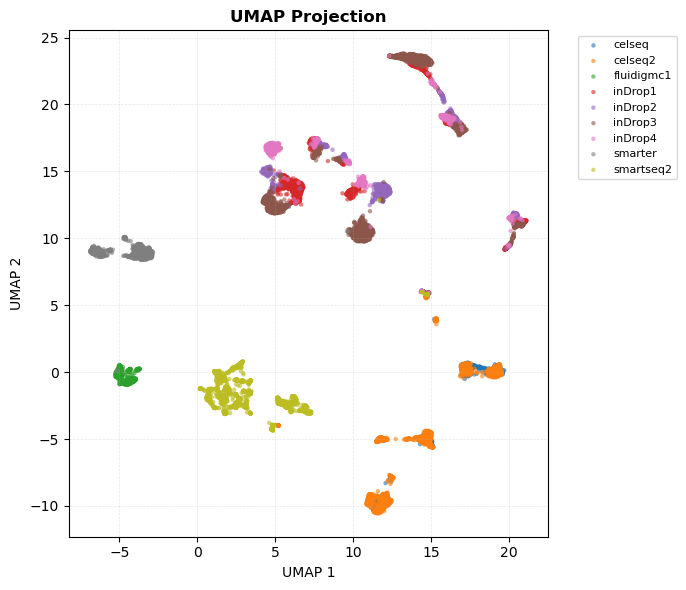

In [27]:
X_intervened = X_encoded.copy()
X_intervened[batch_labels == 'celseq2'] = X_encoded[batch_labels == 'celseq2'] - batch_effects['celseq2'].to_numpy().reshape(1, -1)
umap_plot(X_intervened, batch_labels)

align all batch effects to celseq

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[18.031345 ,  7.9542646],
        [17.7317   ,  8.35682  ],
        [17.80357  ,  8.111491 ],
        ...,
        [17.524252 ,  8.531697 ],
        [18.082504 ,  8.220976 ],
        [17.693378 ,  8.026344 ]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

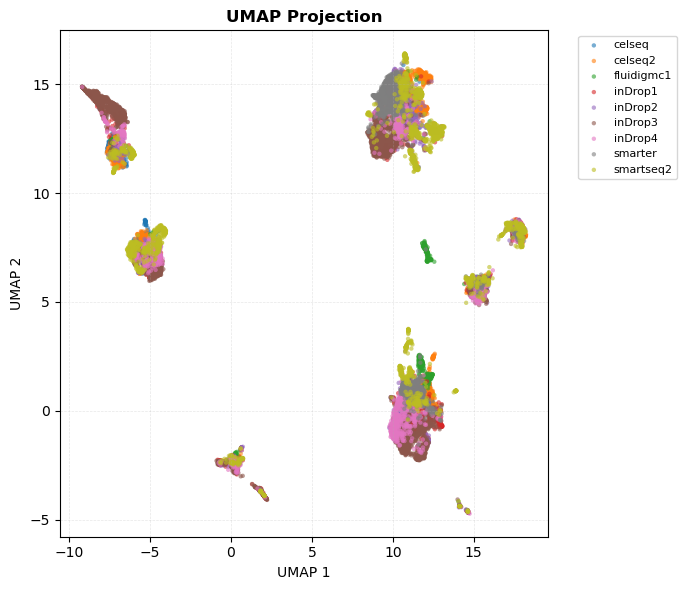

In [28]:
X_batch_moved = X_encoded.copy()
for batch in batch_effects.columns:
    X_batch_moved[batch_labels == batch] = X_encoded[batch_labels == batch] - batch_effects[batch].to_numpy().reshape(1, -1)
umap_plot(X_batch_moved, batch_labels)  

Batch Effects as grand mean shifts. Could be effected by batch-celltype interaction

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-2.183336 , 18.104275 ],
        [-2.1166096, 18.064173 ],
        [-2.2598584, 18.179075 ],
        ...,
        [15.900537 ,  0.8085533],
        [16.024643 ,  1.0467523],
        [15.936119 ,  0.5850538]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

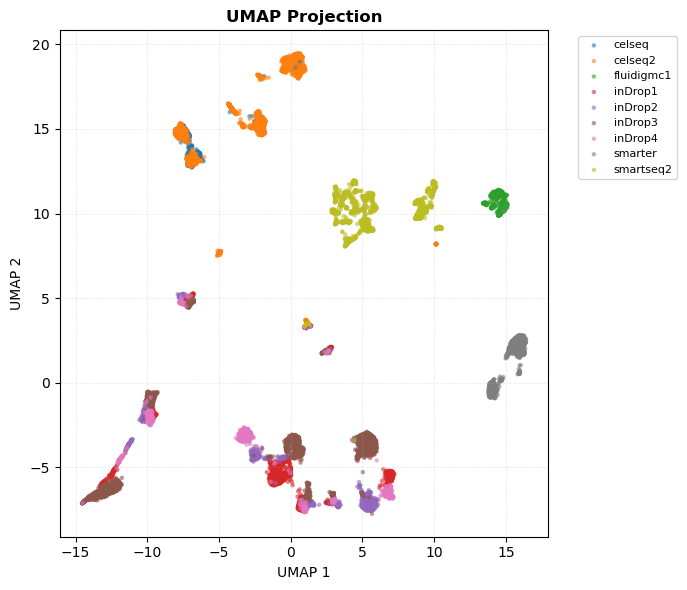

In [29]:
Grand_batch_effects = batch_directions(X_encoded, batch_labels, cell_types=None)
X_grand_batch_moved = X_encoded.copy()
X_grand_batch_moved[batch_labels == 'celseq2'] = X_encoded[batch_labels == 'celseq2'] - Grand_batch_effects['celseq2'].to_numpy().reshape(1, -1)
umap_plot(X_grand_batch_moved, batch_labels)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-9.223872  ,  0.5125162 ],
        [-9.091759  , -0.11612236],
        [-9.193144  ,  0.20090409],
        ...,
        [-8.787493  , -0.4422444 ],
        [-8.837084  , -0.01891815],
        [-8.906575  , -0.15021822]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

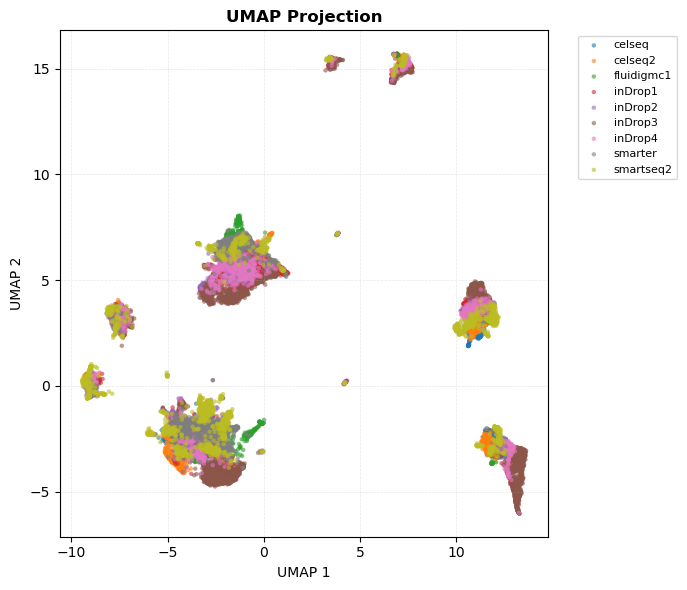

In [30]:
X_grand_batch_moved = X_encoded.copy()
for batch in Grand_batch_effects.columns:
    X_grand_batch_moved[batch_labels == batch] = X_encoded[batch_labels == batch] - Grand_batch_effects[batch].to_numpy().reshape(1, -1)
umap_plot(X_grand_batch_moved, batch_labels)

Performing UMAP on combined dataset (32764 samples, 128 features)...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


(array([[22.29341  ,  4.0567164],
        [22.467491 ,  3.3774886],
        [22.197212 ,  3.7896926],
        ...,
        [22.338459 ,  3.1457913],
        [22.088737 ,  3.4144921],
        [22.11977  ,  3.5415812]], shape=(16382, 2), dtype=float32),
 array([[22.330307 ,  4.0336056],
        [22.442009 ,  3.3231077],
        [22.178238 ,  3.73348  ],
        ...,
        [22.248241 ,  3.0445607],
        [22.11413  ,  3.406045 ],
        [22.250046 ,  3.4736278]], shape=(16382, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

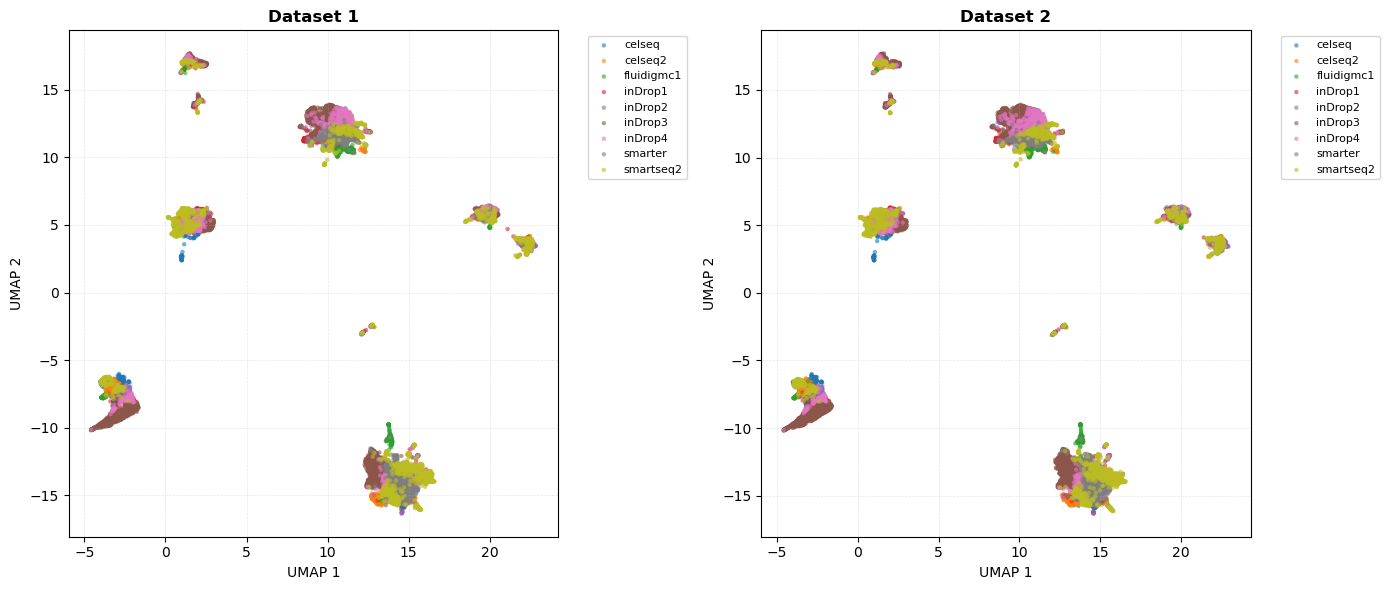

In [32]:
from scdiff.plot import compare_umap
compare_umap(X_batch_moved, X_grand_batch_moved, labels1=batch_labels, labels2=batch_labels)

# Interpolate in diffusion latent space.

In [ ]:
standard_scaler = StandardScaler()
scaled_X_encoded = standard_scaler.fit_transform(X_encoded)


array([[ 1.8710434 ,  1.1259947 , -1.2515061 , ...,  2.5459332 ,
         0.67941743, -1.1863433 ],
       [ 0.5815173 ,  1.1415176 , -2.0232108 , ...,  1.0329893 ,
         0.8511168 , -2.25753   ],
       [ 1.0658662 ,  2.7954493 , -1.6816171 , ...,  2.5308797 ,
        -0.10308188, -3.5462437 ],
       ...,
       [ 0.21494785, -0.4002139 , -1.8068174 , ..., -2.1968043 ,
         0.5165899 , -3.3055718 ],
       [-0.06378136, -0.22712298, -0.6336841 , ..., -2.0875423 ,
         0.81717914, -2.835997  ],
       [ 0.10974124,  0.11055058, -1.5594357 , ..., -0.5617805 ,
        -0.7614474 , -3.1697402 ]], shape=(16382, 128), dtype=float32)